In [1]:
%load_ext autoreload
%autoreload 2
%xmode verbose

Exception reporting mode: Verbose


In [2]:
import pandas
import matplotlib.pyplot as plot
import numpy

data = pandas.read_csv('exoplanet_rm.csv')

data = data[['radius', 'mass']].dropna().reset_index(drop = True)
data = data.sort_values('radius').reset_index(drop = True)

counts = []
result = []
for i in range(len(data['radius'])):
    while data.loc[i, 'radius'] in counts:
        data.loc[i, 'radius'] += 1e-6

    counts.append(data.loc[i, 'radius'])

data = data.sort_values('radius').reset_index(drop = True)
# data = data.drop_duplicates('radius')
data = data.reset_index(drop = True)
data

,radius,mass
0,0.320000,10.00000
1,0.470000,4.30000
2,0.500000,0.20000
3,0.500001,0.10000
4,0.510000,99.20000
...,...,...
1504,23.370765,108.06220
1505,23.538859,375.03752
1506,24.660000,5403.00000
1507,30.264300,3496.13000


In [3]:
r = data['radius']
y = data['mass']

r = numpy.log10(r)
y = numpy.log10(y)

r, y

(0      -0.494850
 1      -0.327902
 2      -0.301030
 3      -0.301029
 4      -0.292430
           ...   
 1504    1.368673
 1505    1.371785
 1506    1.391993
 1507    1.480931
 1508    1.526339
 Name: radius, Length: 1509, dtype: float64,
 0       1.000000
 1       0.633468
 2      -0.698970
 3      -1.000000
 4       1.996512
           ...   
 1504    2.033674
 1505    2.574075
 1506    3.732635
 1507    3.543588
 1508    3.803184
 Name: mass, Length: 1509, dtype: float64)

In [ ]:
import dill
import matplotlib.pyplot as plot
import numpy

with open('radius_mass_model.pkl', 'rb') as file:
    model = dill.load(file)

1.2298364167665525 13.157714393679006


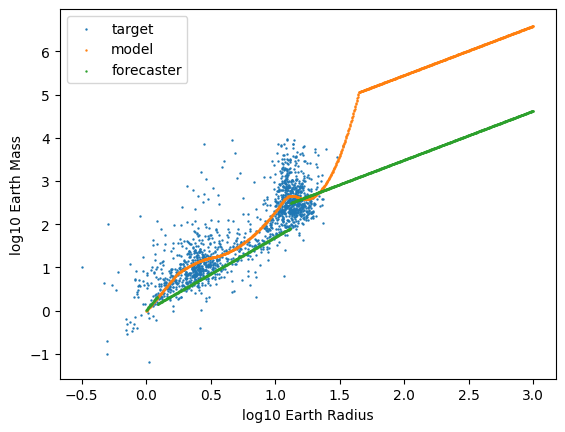

In [ ]:
x = numpy.linspace(0, 3, 1000)
m = model(x) # model

m2 = 0 * m.copy()
R1 = 1.008 * (2.04)**0.279      # Regime 1/2 boundary
R2 = 1.008 * (131.4)**0.589     # Regime 2/3 boundary
R3 = 17.74 * (890)**(-0.044)    # Regime 3/4 boundary
print(R1, R3)
logR1 = numpy.log10(R1)
logR2 = numpy.log10(R2)
logR3 = numpy.log10(R3)

# Regime 1: Rocky planets
w = x < logR1
m2[w] = (1 / 0.279) * numpy.log10((10 ** x[w]) / 1.008)

# Regime 2: Neptunian planets
w = (x >= logR1) & (x < logR3)
m2[w] = (1 / 0.589) * numpy.log10((10 ** x[w]) / 1.008)

# Regime 4: Stellar regime
w = x >= logR3
m2[w] = (1 / 0.881) * numpy.log10((10 ** x[w]) / 11.89)

# m3 = numpy.log10(m3) # simplified chen and kipping

plot.scatter(r, y, s = 0.5)
plot.scatter(x, m, s = 0.5)
plot.scatter(x, m2, s = 0.5)

plot.legend(['target', 'model', 'forecaster'])
plot.xlabel('log10 Earth Radius')
plot.ylabel('log10 Earth Mass')
# plot.xlim(-0.25, 1.5)
# plot.ylim(-1, 5)
plot.show()

In [6]:
r = y - m
r2 = y - m2
plot.scatter(x, r, s = 0.5)
plot.scatter(x, r2, s = 0.5)
plot.show()

ValueError: operands could not be broadcast together with shapes (1509,) (1000,) 

In [ ]:
print(numpy.std(r))
print(numpy.std(r2))